In [2]:
%pip install imbalanced-learn

#import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr
import geopandas as gpd
from shapely.geometry import Point
from sklearn.impute import SimpleImputer
import scipy.stats as stats
from sklearn.neighbors import BallTree
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
from pandas.plotting import parallel_coordinates
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached imbalanced_learn-0.14.0-py3-none-any.whl.metadata (8.8 kB)
Using cached imbalanced_learn-0.14.0-py3-none-any.whl (239 kB)
Note: you may need to restart the kernel to use updated packages.


In [3]:
# read df_final_merged.geojson file in MergedDatasets
import geopandas as gpd
df_final_merged = gpd.read_file('../../MergedDatasets/df_final_merged.geojson')

In [4]:
df_final_merged.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 23180 entries, 0 to 23179
Data columns (total 48 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   match_type         23180 non-null  object  
 1   distance_m         23180 non-null  float64 
 2   cell_id            23180 non-null  int32   
 3   month_1            23180 non-null  object  
 4   month_2            23180 non-null  object  
 5   month_3            23180 non-null  object  
 6   month_4            23180 non-null  object  
 7   month_5            23180 non-null  object  
 8   month_6            23180 non-null  object  
 9   month_7            23180 non-null  object  
 10  month_8            23180 non-null  object  
 11  month_9            23180 non-null  object  
 12  month_10           23180 non-null  object  
 13  month_11           23180 non-null  object  
 14  month_12           23180 non-null  object  
 15  x                  23180 non-null  float64 
 

In [5]:
df_final_merged.head()

,match_type,distance_m,cell_id,month_1,month_2,month_3,month_4,month_5,month_6,month_7,...,area_log,lcc_Bare lands,lcc_Croplands,lcc_Forests,lcc_Grasslands,lcc_Unclassified,lcc_Vegetation,lcc_Water bodies,fire,geometry
0,nearest,5730.516569,0,"[np.float64(8.5), np.float64(22.0), np.float64...","[np.float64(11.0), np.float64(25.0), np.float6...","[np.float64(13.0), np.float64(27.0), np.float6...","[np.float64(18.0), np.float64(32.0), np.float6...","[np.float64(20.0), np.float64(33.75), np.float...","[np.float64(23.0), np.float64(36.75), np.float...","[np.float64(27.75), np.float64(42.0), np.float...",...,26.539949,True,False,False,False,False,False,False,0,"MULTIPOLYGON (((-8.56891 27.26815, -8.56891 27..."
1,nearest,4333.944079,1,"[np.float64(8.0), np.float64(22.0), np.float64...","[np.float64(11.0), np.float64(25.0), np.float6...","[np.float64(13.0), np.float64(27.0), np.float6...","[np.float64(18.0), np.float64(32.0), np.float6...","[np.float64(19.25), np.float64(33.25), np.floa...","[np.float64(22.75), np.float64(36.25), np.floa...","[np.float64(27.0), np.float64(41.75), np.float...",...,26.539949,True,False,False,False,False,False,False,0,"MULTIPOLYGON (((-8.56891 27.36815, -8.56891 27..."
2,nearest,3326.267859,2,"[np.float64(8.5), np.float64(22.0), np.float64...","[np.float64(11.0), np.float64(24.75), np.float...","[np.float64(13.0), np.float64(27.0), np.float6...","[np.float64(17.5), np.float64(31.5), np.float6...","[np.float64(19.0), np.float64(33.0), np.float6...","[np.float64(22.0), np.float64(36.0), np.float6...","[np.float64(27.0), np.float64(41.5), np.float6...",...,26.539949,True,False,False,False,False,False,False,0,"MULTIPOLYGON (((-8.56891 27.46815, -8.56891 27..."
3,nearest,3329.154720,3,"[np.float64(8.0), np.float64(22.0), np.float64...","[np.float64(10.75), np.float64(24.0), np.float...","[np.float64(13.0), np.float64(27.0), np.float6...","[np.float64(17.0), np.float64(31.0), np.float6...","[np.float64(19.0), np.float64(33.0), np.float6...","[np.float64(22.0), np.float64(36.0), np.float6...","[np.float64(27.0), np.float64(41.0), np.float6...",...,26.539949,True,False,False,False,False,False,False,0,"MULTIPOLYGON (((-8.56891 27.56815, -8.56891 27..."
4,nearest,3332.056800,4,"[np.float64(8.0), np.float64(22.0), np.float64...","[np.float64(10.0), np.float64(24.0), np.float6...","[np.float64(12.5), np.float64(27.0), np.float6...","[np.float64(17.0), np.float64(31.0), np.float6...","[np.float64(19.0), np.float64(33.0), np.float6...","[np.float64(22.0), np.float64(36.0), np.float6...","[np.float64(27.0), np.float64(41.0), np.float6...",...,26.539949,True,False,False,False,False,False,False,0,"MULTIPOLYGON (((-8.56891 27.66815, -8.56891 27..."


### Dropping Columns

In [6]:
cols_to_drop = ['geometry', 'cell_id', 'match_type', 'distance_m', 'geometry']
df_final_merged.drop(columns=cols_to_drop, inplace=True)
df_final_merged.shape

(23180, 44)

# **Normalization**

### **Soil**

In [7]:
# Normalization of soil properties according to property-specific methods
# Create a copy to preserve original values
df_soil_normalized = df_final_merged.copy()
# 
# Small constant to avoid log(0)
EPSILON = 1e-6

In [8]:
# 1) Texture (composition): Min-Max (0-1) scaling
texture_cols = ['COARSE_soil', 'SAND_soil', 'SILT_soil', 'CLAY_soil']
for col in texture_cols:
    if col in df_soil_normalized.columns:
        col_min = df_soil_normalized[col].min()
        col_max = df_soil_normalized[col].max()
        if col_max > col_min:
            df_soil_normalized[col] = (df_soil_normalized[col] - col_min) / (col_max - col_min)
        else:
            df_soil_normalized[col] = 0.0
        print(f"{col}: Min-Max scaling applied")


COARSE_soil: Min-Max scaling applied
SAND_soil: Min-Max scaling applied
SILT_soil: Min-Max scaling applied
CLAY_soil: Min-Max scaling applied


In [9]:
# 2) Density & pH: Robust for densities, Min-Max for pH
# Robust scaling: (x - median) / IQR
for col in ['BULK_soil', 'REF_BULK_soil']:
    if col in df_soil_normalized.columns:
        q1 = df_soil_normalized[col].quantile(0.25)
        q3 = df_soil_normalized[col].quantile(0.75)
        median = df_soil_normalized[col].median()
        iqr = q3 - q1
        if iqr > 0:
            df_soil_normalized[col] = (df_soil_normalized[col] - median) / iqr
        else:
            df_soil_normalized[col] = 0.0
        print(f"{col}: Robust scaling applied")

# Min-Max for pH
if 'PH_WATER' in df_soil_normalized.columns:
    col_min = df_soil_normalized['PH_WATER'].min()
    col_max = df_soil_normalized['PH_WATER'].max()
    if col_max > col_min:
        df_soil_normalized['PH_WATER'] = (df_soil_normalized['PH_WATER'] - col_min) / (col_max - col_min)
    else:
        df_soil_normalized['PH_WATER'] = 0.0
    print("PH_WATER: Min-Max scaling applied")


BULK_soil: Robust scaling applied
REF_BULK_soil: Robust scaling applied


In [10]:
# 3) Organic matter & nutrients
# Log + Robust for ORG_CARBON
if 'ORG_CARBON_soil' in df_soil_normalized.columns:
    # treat non-positive / sentinel values as missing before log
    oc = df_soil_normalized['ORG_CARBON_soil'].copy().astype(float)
    oc.loc[oc <= 0] = np.nan

    # log transform (safe with EPSILON)
    oc = np.log(oc + EPSILON)

    # robust scaling: (x - median) / IQR
    q1 = oc.quantile(0.25)
    q3 = oc.quantile(0.75)
    median = oc.median()
    iqr = q3 - q1
    if iqr > 0:
        oc = (oc - median) / iqr
    else:
        oc = oc - median

    # fill remaining NaNs with median of transformed values (robust fallback)
    oc = oc.fillna(oc.median())

    df_soil_normalized['ORG_CARBON_soil'] = oc
    print("ORG_CARBON: Log + Robust scaling applied")

# Log for TOTAL_N (then standard scale)
if 'TOTAL_N_soil' in df_soil_normalized.columns:
    df_soil_normalized['TOTAL_N_soil'] = np.log(df_soil_normalized['TOTAL_N_soil'] + EPSILON)
    mean_val = df_soil_normalized['TOTAL_N_soil'].mean()
    std_val = df_soil_normalized['TOTAL_N_soil'].std()
    if std_val > 0:
        df_soil_normalized['TOTAL_N_soil'] = (df_soil_normalized['TOTAL_N_soil'] - mean_val) / std_val
    else:
        df_soil_normalized['TOTAL_N_soil'] = 0.0
    print("TOTAL_N: Log + Standard scaling applied")

# Min-Max for TCARBON_EQ
if 'TCARBON_EQ_soil' in df_soil_normalized.columns:
    col_min = df_soil_normalized['TCARBON_EQ_soil'].min()
    col_max = df_soil_normalized['TCARBON_EQ_soil'].max()
    if col_max > col_min:
        df_soil_normalized['TCARBON_EQ_soil'] = (df_soil_normalized['TCARBON_EQ_soil'] - col_min) / (col_max - col_min)
    else:
        df_soil_normalized['TCARBON_EQ_soil'] = 0.0
    print("TCARBON_EQ: Min-Max scaling applied")


ORG_CARBON: Log + Robust scaling applied
TOTAL_N: Log + Standard scaling applied
TCARBON_EQ: Min-Max scaling applied


In [11]:
# 4) Cation exchange & fertility: Robust (CEC_SOIL, CEC_EFF,  TEB), Min-Max (CEC_CLAY, BSAT)
for col in ['CEC_SOIL_soil', 'CEC_EFF_soil', 'TEB_soil']:
    if col in df_soil_normalized.columns:
        q1 = df_soil_normalized[col].quantile(0.25)
        q3 = df_soil_normalized[col].quantile(0.75)
        median = df_soil_normalized[col].median()
        iqr = q3 - q1
        if iqr > 0:
            df_soil_normalized[col] = (df_soil_normalized[col] - median) / iqr
        else:
            df_soil_normalized[col] = 0.0
        print(f"{col}: Robust scaling applied")

for col in ['CEC_CLAY_soil', 'BSAT_soil']:
    if col in df_soil_normalized.columns:
        col_min = df_soil_normalized[col].min()
        col_max = df_soil_normalized[col].max()
        if col_max > col_min:
            df_soil_normalized[col] = (df_soil_normalized[col] - col_min) / (col_max - col_min)
        else:
            df_soil_normalized[col] = 0.0
        print(f"{col}: Min-Max scaling applied")

CEC_SOIL_soil: Robust scaling applied
CEC_EFF_soil: Robust scaling applied
TEB_soil: Robust scaling applied
CEC_CLAY_soil: Min-Max scaling applied
BSAT_soil: Min-Max scaling applied


In [12]:
# 5) Salinity & saturation: Log + Robust Scaling
for col in ['ALUM_SAT_soil', 'ESP_soil', 'GYPSUM_soil', 'ELEC_COND_soil']:
    if col in df_soil_normalized.columns:
        df_soil_normalized[col] = np.log(df_soil_normalized[col] + EPSILON)
        q1 = df_soil_normalized[col].quantile(0.25)
        q3 = df_soil_normalized[col].quantile(0.75)
        median = df_soil_normalized[col].median()
        iqr = q3 - q1
        if iqr > 0:
            df_soil_normalized[col] = (df_soil_normalized[col] - median) / iqr
        else:
            df_soil_normalized[col] = 0.0
        print(f"{col}: Log + Robust scaling applied")


ALUM_SAT_soil: Log + Robust scaling applied
ESP_soil: Log + Robust scaling applied
GYPSUM_soil: Log + Robust scaling applied
ELEC_COND_soil: Log + Robust scaling applied


In [13]:
print("\nAll normalization transformations completed")
print(f"Original shape: {df_final_merged.shape}")
print(f"Normalized shape: {df_soil_normalized.shape}")



All normalization transformations completed
Original shape: (23180, 44)
Normalized shape: (23180, 44)


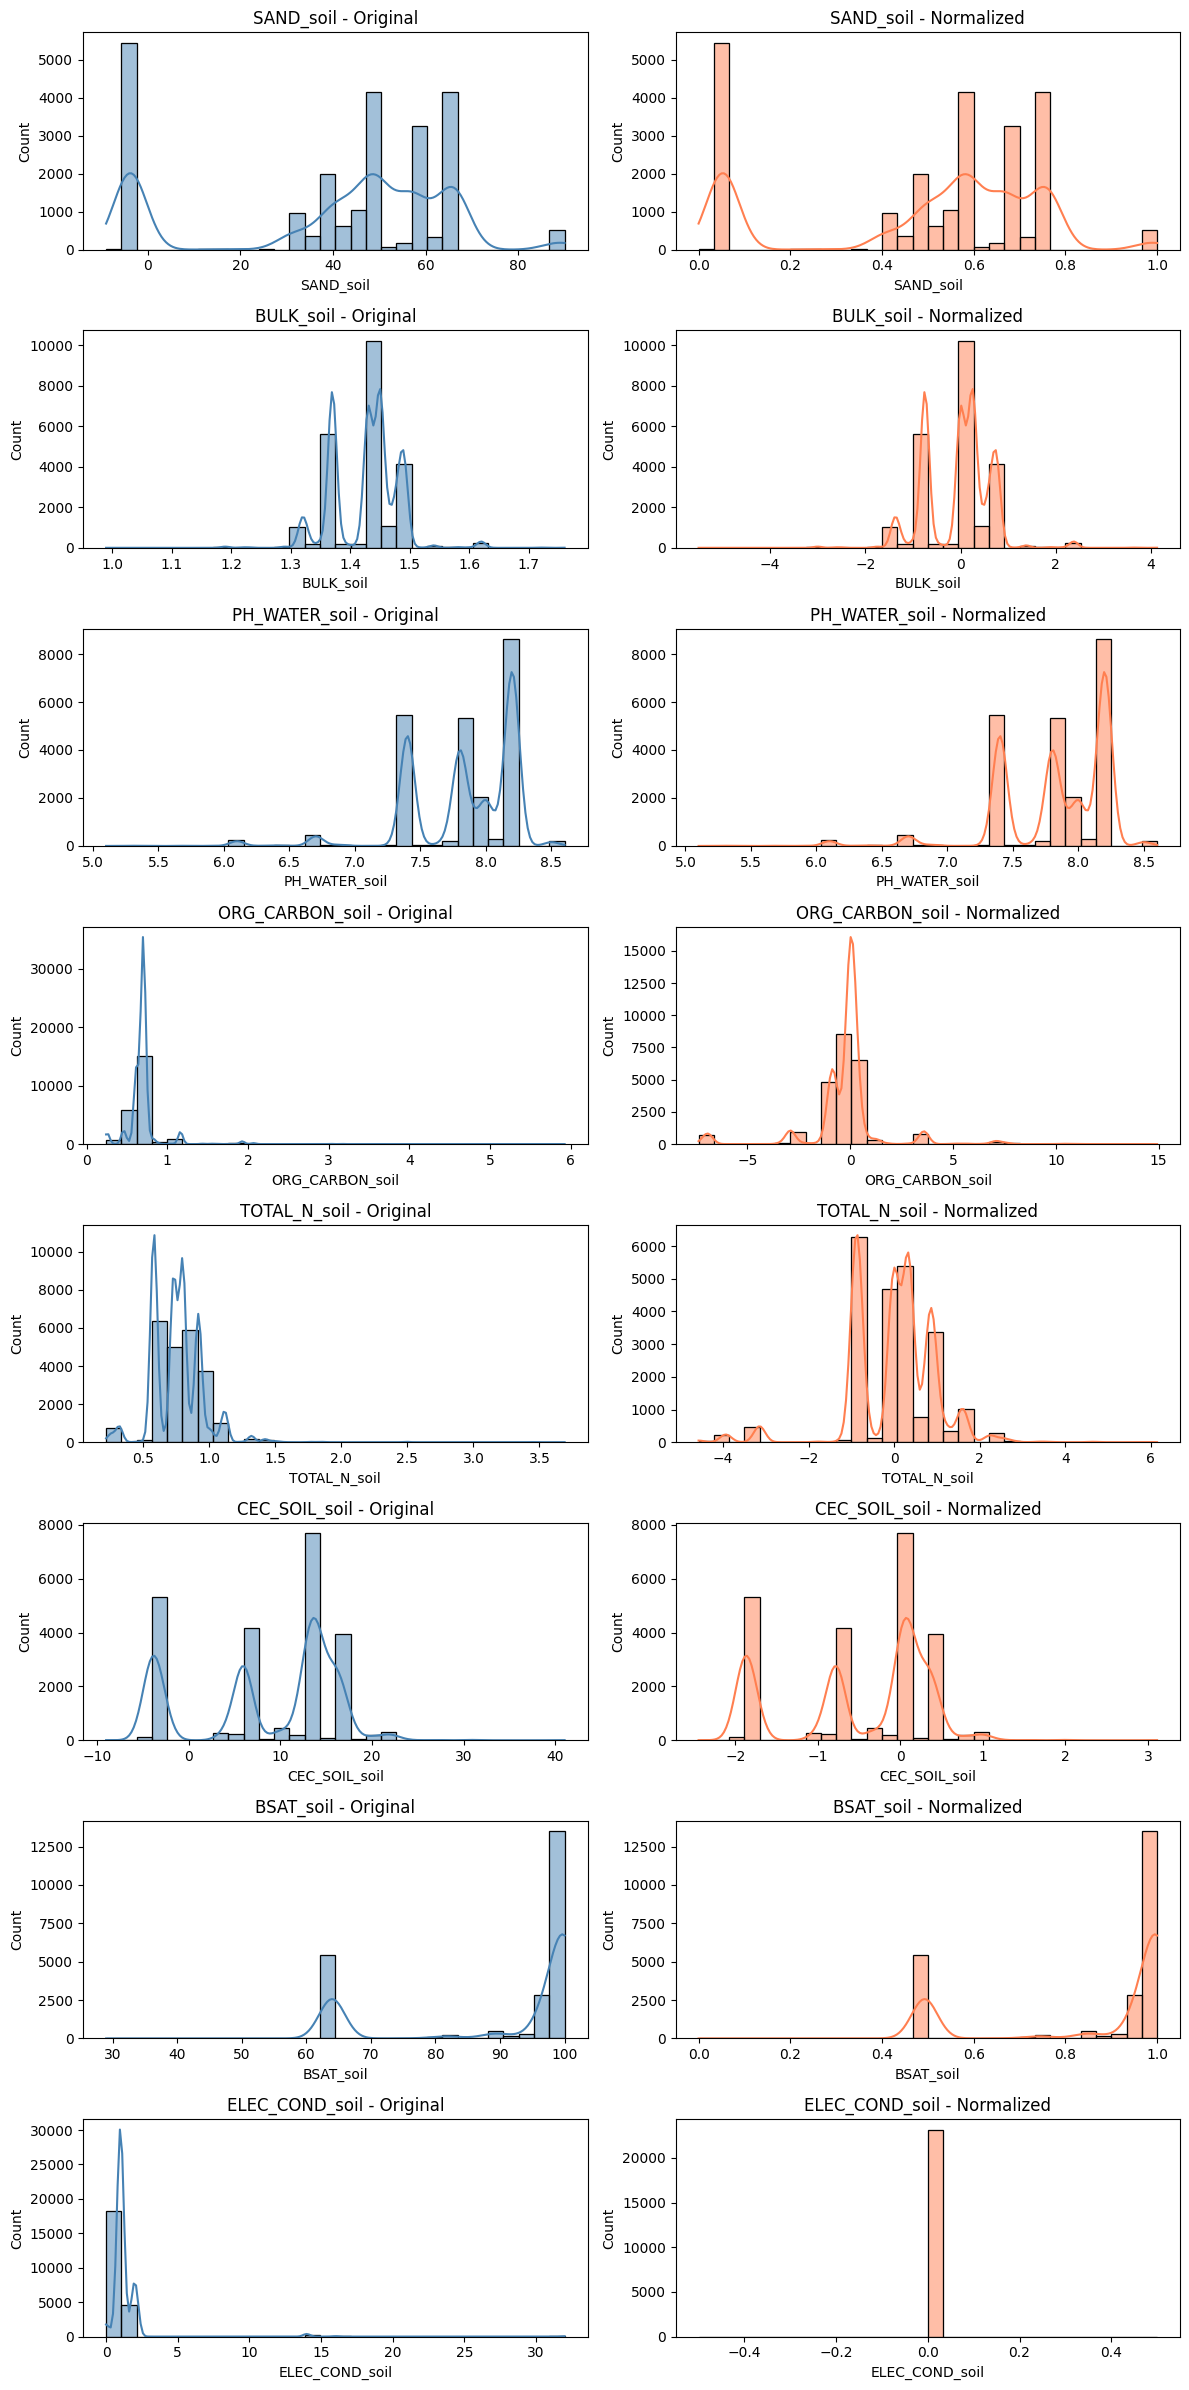

In [14]:
# Compare distributions before and after normalization
# Select a subset of key columns to visualize
comparison_cols = ['SAND_soil', 'BULK_soil', 'PH_WATER_soil', 'ORG_CARBON_soil', 'TOTAL_N_soil', 
                   'CEC_SOIL_soil', 'BSAT_soil', 'ELEC_COND_soil']

# Filter to only columns that exist in both dataframes
comparison_cols = [c for c in comparison_cols if c in df_final_merged.columns and c in df_soil_normalized.columns]

n = len(comparison_cols)
if n > 0:
    ncols = 2  # Before and After side by side
    nrows = n
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3*nrows))
    
    if n == 1:
        axes = axes.reshape(1, -1)
    
    for i, col in enumerate(comparison_cols):
        # Before (original)
        ax_before = axes[i, 0]
        data_before = df_final_merged[col].dropna()
        if not data_before.empty:
            sns.histplot(data_before, bins=30, kde=True, ax=ax_before, color='steelblue')
            ax_before.set_title(f"{col} - Original")
            ax_before.set_xlabel(col)
            ax_before.set_ylabel("Count")
        else:
            ax_before.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax_before.transAxes)
        
        # After (normalized)
        ax_after = axes[i, 1]
        data_after = df_soil_normalized[col].dropna()
        if not data_after.empty:
            sns.histplot(data_after, bins=30, kde=True, ax=ax_after, color='coral')
            ax_after.set_title(f"{col} - Normalized")
            ax_after.set_xlabel(col)
            ax_after.set_ylabel("Count")
        else:
            ax_after.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax_after.transAxes)
    
    plt.tight_layout()
    plt.savefig('../../Rapport_TP/images/MergedPreprocess/soil_normalization_comparison.png')
    plt.show()
else:
    print("No columns available for comparison visualization")


In [15]:
# Summary statistics: compare ranges and distributions before/after normalization
numeric_features = ['COARSE_soil', 'SAND_soil', 'SILT_soil', 'CLAY_soil', 'BULK_soil', 'REF_BULK_soil', 
                    'ORG_CARBON_soil', 'PH_WATER_soil', 'TOTAL_N_soil', 'CEC_SOIL_soil', 'CEC_CLAY_soil', 
                    'CEC_EFF_soil', 'TEB_soil', 'BSAT_soil', 'ALUM_SAT_soil', 'ESP_soil', 'TCARBON_EQ_soil', 
                    'GYPSUM_soil', 'ELEC_COND_soil']

# Filter to existing columns
numeric_features = [c for c in numeric_features if c in df_final_merged.columns and c in df_soil_normalized.columns]

summary_comparison = pd.DataFrame({
    'Original_Min': df_final_merged[numeric_features].min(),
    'Original_Max': df_final_merged[numeric_features].max(),
    'Original_Mean': df_final_merged[numeric_features].mean(),
    'Original_Std': df_final_merged[numeric_features].std(),
    'Normalized_Min': df_soil_normalized[numeric_features].min(),
    'Normalized_Max': df_soil_normalized[numeric_features].max(),
    'Normalized_Mean': df_soil_normalized[numeric_features].mean(),
    'Normalized_Std': df_soil_normalized[numeric_features].std()
})

print("Summary Statistics Comparison (Original vs Normalized)")
print("=" * 80)
display(summary_comparison.round(4))


Summary Statistics Comparison (Original vs Normalized)


,Original_Min,Original_Max,Original_Mean,Original_Std,Normalized_Min,Normalized_Max,Normalized_Mean,Normalized_Std
COARSE_soil,-9.000,46.000,7.7714,7.9554,0.0000,1.0000,0.3049,0.1446
SAND_soil,-9.000,90.000,39.7070,26.3766,0.0000,1.0000,0.4920,0.2664
SILT_soil,-9.000,46.000,21.6849,15.6058,0.0000,1.0000,0.5579,0.2837
CLAY_soil,-9.000,55.000,12.3412,10.1603,0.0000,1.0000,0.3335,0.1588
BULK_soil,0.990,1.760,1.4274,0.0543,-5.5000,4.1250,-0.0325,0.6788
REF_BULK_soil,1.200,2.030,1.6499,0.0980,-3.6800,2.9600,-0.0807,0.7844
ORG_CARBON_soil,0.242,5.923,0.6993,0.2168,-7.3756,14.9193,-0.2227,1.8223
PH_WATER_soil,5.100,8.600,7.8345,0.4157,5.1000,8.6000,7.8345,0.4157
TOTAL_N_soil,0.220,3.690,0.7571,0.1913,-4.5746,6.1441,-0.0000,1.0000
CEC_SOIL_soil,-9.000,41.000,8.4999,7.8432,-2.4444,3.1111,-0.5000,0.8715


## **Climate**

In [16]:
df_soil_normalized.head()

,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,...,elevation,area_log,lcc_Bare lands,lcc_Croplands,lcc_Forests,lcc_Grasslands,lcc_Unclassified,lcc_Vegetation,lcc_Water bodies,fire
0,"[np.float64(8.5), np.float64(22.0), np.float64...","[np.float64(11.0), np.float64(25.0), np.float6...","[np.float64(13.0), np.float64(27.0), np.float6...","[np.float64(18.0), np.float64(32.0), np.float6...","[np.float64(20.0), np.float64(33.75), np.float...","[np.float64(23.0), np.float64(36.75), np.float...","[np.float64(27.75), np.float64(42.0), np.float...","[np.float64(27.0), np.float64(41.0), np.float6...","[np.float64(23.0), np.float64(36.0), np.float6...","[np.float64(18.0), np.float64(31.0), np.float6...",...,452.0,26.539949,True,False,False,False,False,False,False,0
1,"[np.float64(8.0), np.float64(22.0), np.float64...","[np.float64(11.0), np.float64(25.0), np.float6...","[np.float64(13.0), np.float64(27.0), np.float6...","[np.float64(18.0), np.float64(32.0), np.float6...","[np.float64(19.25), np.float64(33.25), np.floa...","[np.float64(22.75), np.float64(36.25), np.floa...","[np.float64(27.0), np.float64(41.75), np.float...","[np.float64(27.0), np.float64(41.0), np.float6...","[np.float64(23.0), np.float64(36.0), np.float6...","[np.float64(18.0), np.float64(31.0), np.float6...",...,460.0,26.539949,True,False,False,False,False,False,False,0
2,"[np.float64(8.5), np.float64(22.0), np.float64...","[np.float64(11.0), np.float64(24.75), np.float...","[np.float64(13.0), np.float64(27.0), np.float6...","[np.float64(17.5), np.float64(31.5), np.float6...","[np.float64(19.0), np.float64(33.0), np.float6...","[np.float64(22.0), np.float64(36.0), np.float6...","[np.float64(27.0), np.float64(41.5), np.float6...","[np.float64(27.0), np.float64(41.0), np.float6...","[np.float64(22.75), np.float64(36.0), np.float...","[np.float64(18.0), np.float64(31.0), np.float6...",...,459.0,26.539949,True,False,False,False,False,False,False,0
3,"[np.float64(8.0), np.float64(22.0), np.float64...","[np.float64(10.75), np.float64(24.0), np.float...","[np.float64(13.0), np.float64(27.0), np.float6...","[np.float64(17.0), np.float64(31.0), np.float6...","[np.float64(19.0), np.float64(33.0), np.float6...","[np.float64(22.0), np.float64(36.0), np.float6...","[np.float64(27.0), np.float64(41.0), np.float6...","[np.float64(26.75), np.float64(41.0), np.float...","[np.float64(22.0), np.float64(36.0), np.float6...","[np.float64(18.0), np.float64(31.0), np.float6...",...,465.0,26.539949,True,False,False,False,False,False,False,0
4,"[np.float64(8.0), np.float64(22.0), np.float64...","[np.float64(10.0), np.float64(24.0), np.float6...","[np.float64(12.5), np.float64(27.0), np.float6...","[np.float64(17.0), np.float64(31.0), np.float6...","[np.float64(19.0), np.float64(33.0), np.float6...","[np.float64(22.0), np.float64(36.0), np.float6...","[np.float64(27.0), np.float64(41.0), np.float6...","[np.float64(26.25), np.float64(41.0), np.float...","[np.float64(22.0), np.float64(36.0), np.float6...","[np.float64(18.0), np.float64(31.0), np.float6...",...,470.0,26.539949,True,False,False,False,False,False,False,0


In [17]:
# Expand monthly climate columns with enhanced parsing and imputation
df_climate_expanded = df_soil_normalized.copy()
climate_cols = ['month_1', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6',
                'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12']
import ast
import re

def parse_triplet(val):
    # Already a list/tuple/array
    if isinstance(val, (list, tuple, np.ndarray)):
        if len(val) >= 3:
            try:
                return [float(val[0]), float(val[1]), float(val[2])]
            except:
                return np.nan
        return np.nan
    
    if pd.isna(val):
        return np.nan
    
    if isinstance(val, (float, int, np.number)):
        return np.nan
    
    if isinstance(val, str):
        s = val.strip()
        if not s:
            return np.nan
        
        # Remove common wrappers
        s = s.replace('np.float64', '').replace('array', '')
        s = s.replace('(', ' ').replace(')', ' ')
        
        # Try literal eval first for clean lists
        if s.strip().startswith('[') and s.strip().endswith(']'):
            try:
                out = ast.literal_eval(s.strip())
                if isinstance(out, (list, tuple)) and len(out) >= 3:
                    return [float(out[0]), float(out[1]), float(out[2])]
            except:
                pass
        
        # Extract all numbers using regex
        nums = re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', s)
        if len(nums) >= 3:
            try:
                return [float(nums[0]), float(nums[1]), float(nums[2])]
            except:
                return np.nan
    
    return np.nan

# Store raw values for diagnostics
raw_month_values = {}
for col in climate_cols:
    if col in df_climate_expanded.columns:
        raw_month_values[col] = df_climate_expanded[col].copy()

# Parse triplets
parsed_stats = {}
for col in climate_cols:
    if col in df_climate_expanded.columns:
        df_climate_expanded[col] = df_climate_expanded[col].apply(parse_triplet)
        
        # Diagnostics
        total = len(df_climate_expanded)
        valid = df_climate_expanded[col].apply(lambda x: isinstance(x, list) and len(x) == 3).sum()
        parsed_stats[col] = (valid, total)
        
        # Sample unparsed values
        if valid < total:
            failed_mask = ~df_climate_expanded[col].apply(lambda x: isinstance(x, list) and len(x) == 3)
            samples = raw_month_values[col][failed_mask].dropna().astype(str).head(3).tolist()
            print(f"{col}: {valid}/{total} parsed ({100*valid/total:.1f}%) | Sample unparsed: {samples}")

# Expand into separate columns
for i, col in enumerate(climate_cols, start=1):
    if col in df_climate_expanded.columns:
        df_climate_expanded[f'temp_min_{i}'] = df_climate_expanded[col].apply(
            lambda x: x[0] if isinstance(x, list) and len(x) == 3 else np.nan)
        df_climate_expanded[f'temp_max_{i}'] = df_climate_expanded[col].apply(
            lambda x: x[1] if isinstance(x, list) and len(x) == 3 else np.nan)
        df_climate_expanded[f'precip_{i}'] = df_climate_expanded[col].apply(
            lambda x: x[2] if isinstance(x, list) and len(x) == 3 else np.nan)
        df_climate_expanded.drop(columns=[col], inplace=True)

# Report NaNs before imputation
climate_columns = [c for c in df_climate_expanded.columns 
                   if c.startswith('temp_min_') or c.startswith('temp_max_') or c.startswith('precip_')]
nan_before = df_climate_expanded[climate_columns].isna().sum()
print("\n=== NaNs before imputation ===")
print(nan_before[nan_before > 0])

# Imputation: column-wise mean for each variable type
for prefix in ['temp_min', 'temp_max', 'precip']:
    cols = [f'{prefix}_{i}' for i in range(1, 13) if f'{prefix}_{i}' in df_climate_expanded.columns]
    if cols:
        # Per-column mean imputation
        for col in cols:
            col_mean = df_climate_expanded[col].mean(skipna=True)
            df_climate_expanded[col].fillna(col_mean, inplace=True)
        
        # Overall mean as fallback for rows that are still all NaN
        overall_mean = df_climate_expanded[cols].mean(skipna=True).mean()
        for col in cols:
            df_climate_expanded[col].fillna(overall_mean, inplace=True)

# Report NaNs after imputation
nan_after = df_climate_expanded[climate_columns].isna().sum()
print("\n=== NaNs after imputation ===")
if nan_after.sum() == 0:
    print("All NaNs successfully imputed!")
else:
    print(nan_after[nan_after > 0])

print(f"\n✓ Climate expansion complete: {len(climate_columns)} new columns created")


=== NaNs before imputation ===
Series([], dtype: int64)

=== NaNs after imputation ===
All NaNs successfully imputed!

✓ Climate expansion complete: 36 new columns created


C:\Users\E15\AppData\Local\Temp\ipykernel_26628\3078293989.py:100: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_climate_expanded[col].fillna(col_mean, inplace=True)
C:\Users\E15\AppData\Local\Temp\ipykernel_26628\3078293989.py:105: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.



In [18]:
df_climate_expanded.head()

,x,y,HWSD2_SMU_ID_soil,COARSE_soil,SAND_soil,SILT_soil,CLAY_soil,BULK_soil,REF_BULK_soil,ORG_CARBON_soil,...,precip_9,temp_min_10,temp_max_10,precip_10,temp_min_11,temp_max_11,precip_11,temp_min_12,temp_max_12,precip_12
0,-8.574054,27.262808,1830,0.381818,0.585859,0.763636,0.421875,0.250001,0.16,0.0,...,52.099998,18.0,31.0,7.625,14.0,27.0,6.125,8.0,22.00,4.100
1,-8.618508,27.341545,1830,0.381818,0.585859,0.763636,0.421875,0.250001,0.16,0.0,...,51.900002,18.0,31.0,7.150,14.0,27.0,6.200,8.0,21.75,4.100
2,-8.618494,27.423112,1844,0.381818,0.585859,0.763636,0.421875,0.250001,0.16,0.0,...,52.450001,18.0,31.0,8.125,13.5,27.0,6.450,8.0,21.25,5.300
3,-8.618481,27.495017,1844,0.381818,0.585859,0.763636,0.421875,0.250001,0.16,0.0,...,52.750000,18.0,31.0,8.100,13.0,27.0,7.325,8.0,21.00,5.625
4,-8.618457,27.631494,1844,0.381818,0.585859,0.763636,0.421875,0.250001,0.16,0.0,...,53.025002,18.0,31.0,8.100,13.0,26.0,7.300,8.0,21.00,6.500


In [19]:
df_climate_normalized=df_climate_expanded.copy()
# Normalize climate features: Standard scaling (z-score)
temp_features = [c for c in df_climate_normalized.columns if c.startswith('temp_min_') or c.startswith('temp_max_') ]
scaler = StandardScaler()
df_climate_normalized[temp_features] = scaler.fit_transform(df_climate_normalized[temp_features])

In [20]:
# log transform for precipitation
precip_features = [c for c in df_climate_normalized.columns if c.startswith('precip_') ]
for col in precip_features:
    df_climate_normalized[col] = np.log(df_climate_normalized[col] + 1e-6)

## **Elevation**

In [21]:
#standard scaler elevation
elev_features = ['elevation']
scaler_elev = StandardScaler()
df_climate_normalized[elev_features] = scaler_elev.fit_transform(df_climate_normalized[elev_features])

In [22]:
df_final_normalized=df_climate_normalized.copy()

## **LandCover**

In [23]:
landcover_col =[c for c in df_final_normalized.columns if c.startswith('lcc')]
#check unique values
for col in landcover_col:
    print(f"Unique values in {col}: {df_final_normalized[col].unique()}")

Unique values in lcc_Bare lands: [ True False]
Unique values in lcc_Croplands: [False  True]
Unique values in lcc_Forests: [False  True]
Unique values in lcc_Grasslands: [False  True]
Unique values in lcc_Unclassified: [False]
Unique values in lcc_Vegetation: [False  True]
Unique values in lcc_Water bodies: [False  True]


In [24]:
#turn False and True into 0 and 1
for col in landcover_col:
    df_final_normalized[col] = df_final_normalized[col].astype(int)
df_final_normalized.head()

,x,y,HWSD2_SMU_ID_soil,COARSE_soil,SAND_soil,SILT_soil,CLAY_soil,BULK_soil,REF_BULK_soil,ORG_CARBON_soil,...,precip_9,temp_min_10,temp_max_10,precip_10,temp_min_11,temp_max_11,precip_11,temp_min_12,temp_max_12,precip_12
0,-8.574054,27.262808,1830,0.381818,0.585859,0.763636,0.421875,0.250001,0.16,0.0,...,3.953165,-0.263394,-0.380946,2.031432,0.754828,0.222290,1.812379,0.713404,0.398107,1.410987
1,-8.618508,27.341545,1830,0.381818,0.585859,0.763636,0.421875,0.250001,0.16,0.0,...,3.949319,-0.263394,-0.380946,1.967112,0.754828,0.222290,1.824549,0.713404,0.338070,1.410987
2,-8.618494,27.423112,1844,0.381818,0.585859,0.763636,0.421875,0.250001,0.16,0.0,...,3.959860,-0.263394,-0.380946,2.094946,0.525880,0.222290,1.864080,0.713404,0.217996,1.667707
3,-8.618481,27.495017,1844,0.381818,0.585859,0.763636,0.421875,0.250001,0.16,0.0,...,3.965564,-0.263394,-0.380946,2.091864,0.296931,0.222290,1.991293,0.713404,0.157959,1.727221
4,-8.618457,27.631494,1844,0.381818,0.585859,0.763636,0.421875,0.250001,0.16,0.0,...,3.970764,-0.263394,-0.380946,2.091864,0.296931,-0.065987,1.987875,0.713404,0.157959,1.871802


## **Target**

In [25]:
#turn fire into 0 and 1
df_final_normalized['fire'] = df_final_normalized['fire'].astype(int)
df_final_normalized.head()

,x,y,HWSD2_SMU_ID_soil,COARSE_soil,SAND_soil,SILT_soil,CLAY_soil,BULK_soil,REF_BULK_soil,ORG_CARBON_soil,...,precip_9,temp_min_10,temp_max_10,precip_10,temp_min_11,temp_max_11,precip_11,temp_min_12,temp_max_12,precip_12
0,-8.574054,27.262808,1830,0.381818,0.585859,0.763636,0.421875,0.250001,0.16,0.0,...,3.953165,-0.263394,-0.380946,2.031432,0.754828,0.222290,1.812379,0.713404,0.398107,1.410987
1,-8.618508,27.341545,1830,0.381818,0.585859,0.763636,0.421875,0.250001,0.16,0.0,...,3.949319,-0.263394,-0.380946,1.967112,0.754828,0.222290,1.824549,0.713404,0.338070,1.410987
2,-8.618494,27.423112,1844,0.381818,0.585859,0.763636,0.421875,0.250001,0.16,0.0,...,3.959860,-0.263394,-0.380946,2.094946,0.525880,0.222290,1.864080,0.713404,0.217996,1.667707
3,-8.618481,27.495017,1844,0.381818,0.585859,0.763636,0.421875,0.250001,0.16,0.0,...,3.965564,-0.263394,-0.380946,2.091864,0.296931,0.222290,1.991293,0.713404,0.157959,1.727221
4,-8.618457,27.631494,1844,0.381818,0.585859,0.763636,0.421875,0.250001,0.16,0.0,...,3.970764,-0.263394,-0.380946,2.091864,0.296931,-0.065987,1.987875,0.713404,0.157959,1.871802


### **SPLIT**

In [26]:
# train test split test validation
from sklearn.model_selection import train_test_split
X = df_final_normalized.drop(columns=['fire'])
y = df_final_normalized['fire']
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

### **Sampling**

=== Original Class Distribution ===
Train set: {0: 15285, 1: 941}
Train ratio: {0: 0.9420066559842228, 1: 0.057993344015777146}

=== Applying SMOTE ===
SMOTE train set: {0: 15285, 1: 15285}
SMOTE ratio: {0: 0.5, 1: 0.5}

=== Applying Tomek Links ===
SMOTE train set: {0: 15285, 1: 15285}
SMOTE ratio: {0: 0.5, 1: 0.5}

=== Applying Tomek Links ===
Tomek train set: {0: 14975, 1: 941}
Tomek ratio: {0: 0.940877104800201, 1: 0.05912289519979894}

=== Applying SMOTE + Tomek Links ===
Tomek train set: {0: 14975, 1: 941}
Tomek ratio: {0: 0.940877104800201, 1: 0.05912289519979894}

=== Applying SMOTE + Tomek Links ===
SMOTE+Tomek train set: {0: 15252, 1: 15252}
SMOTE+Tomek ratio: {0: 0.5, 1: 0.5}

=== Resampling Summary ===
SMOTE+Tomek train set: {0: 15252, 1: 15252}
SMOTE+Tomek ratio: {0: 0.5, 1: 0.5}

=== Resampling Summary ===


,Method,Total_Samples,Class_0,Class_1,Balance_Ratio
0,Original,16226,15285,941,0.061564
1,SMOTE,30570,15285,15285,1.000000
2,Tomek,15916,14975,941,0.062838
3,SMOTE+Tomek,30504,15252,15252,1.000000


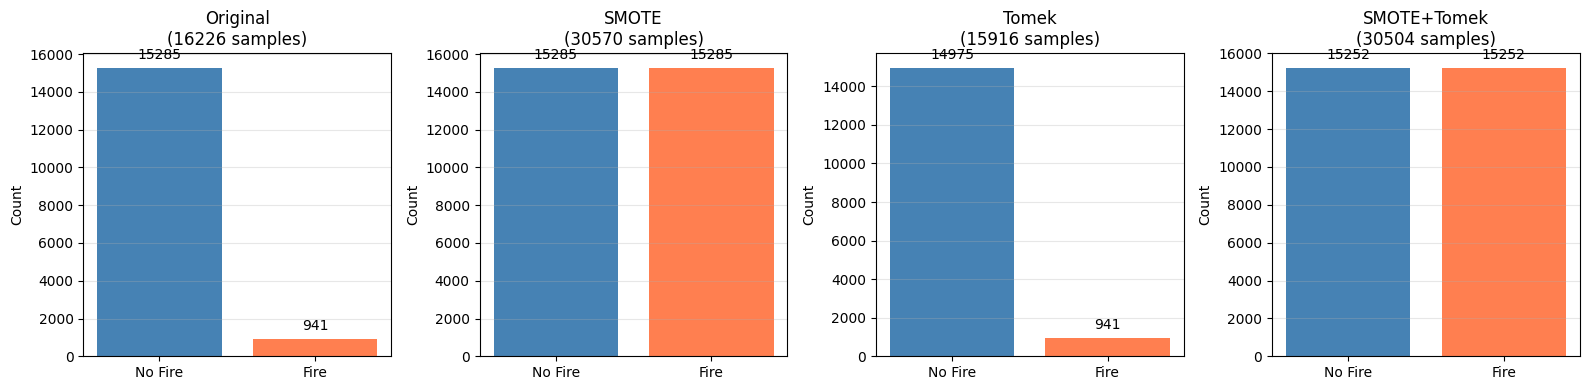


✓ All resampling techniques applied successfully!


In [27]:
# Apply different resampling techniques: SMOTE, Tomek Links, and SMOTE+Tomek
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek

# Check original class distribution
print("=== Original Class Distribution ===")
print(f"Train set: {y_train.value_counts().to_dict()}")
print(f"Train ratio: {y_train.value_counts(normalize=True).to_dict()}")

# 1) SMOTE (Synthetic Minority Over-sampling Technique)
print("\n=== Applying SMOTE ===")
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"SMOTE train set: {y_train_smote.value_counts().to_dict()}")
print(f"SMOTE ratio: {y_train_smote.value_counts(normalize=True).to_dict()}")

# 2) Tomek Links (Under-sampling by removing Tomek pairs)
print("\n=== Applying Tomek Links ===")
tomek = TomekLinks(sampling_strategy='auto')
X_train_tomek, y_train_tomek = tomek.fit_resample(X_train, y_train)
print(f"Tomek train set: {y_train_tomek.value_counts().to_dict()}")
print(f"Tomek ratio: {y_train_tomek.value_counts(normalize=True).to_dict()}")

# 3) SMOTE + Tomek Links (Combined approach)
print("\n=== Applying SMOTE + Tomek Links ===")
smote_tomek = SMOTETomek(random_state=42, smote=SMOTE(random_state=42, k_neighbors=5))
X_train_smote_tomek, y_train_smote_tomek = smote_tomek.fit_resample(X_train, y_train)
print(f"SMOTE+Tomek train set: {y_train_smote_tomek.value_counts().to_dict()}")
print(f"SMOTE+Tomek ratio: {y_train_smote_tomek.value_counts(normalize=True).to_dict()}")

# Summary comparison
print("\n=== Resampling Summary ===")
summary_df = pd.DataFrame({
    'Method': ['Original', 'SMOTE', 'Tomek', 'SMOTE+Tomek'],
    'Total_Samples': [
        len(y_train),
        len(y_train_smote),
        len(y_train_tomek),
        len(y_train_smote_tomek)
    ],
    'Class_0': [
        (y_train == 0).sum(),
        (y_train_smote == 0).sum(),
        (y_train_tomek == 0).sum(),
        (y_train_smote_tomek == 0).sum()
    ],
    'Class_1': [
        (y_train == 1).sum(),
        (y_train_smote == 1).sum(),
        (y_train_tomek == 1).sum(),
        (y_train_smote_tomek == 1).sum()
    ]
})
summary_df['Balance_Ratio'] = summary_df['Class_1'] / summary_df['Class_0']
display(summary_df)

# Visualize class distributions
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
datasets = [
    (y_train, 'Original'),
    (y_train_smote, 'SMOTE'),
    (y_train_tomek, 'Tomek'),
    (y_train_smote_tomek, 'SMOTE+Tomek')
]

for ax, (y_data, title) in zip(axes, datasets):
    counts = y_data.value_counts().sort_index()
    ax.bar(['No Fire', 'Fire'], counts.values, color=['steelblue', 'coral'])
    ax.set_title(f'{title}\n({len(y_data)} samples)')
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(counts.values):
        ax.text(i, v + max(counts.values)*0.02, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../../Rapport_TP/images/MergedPreprocess/resampling_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ All resampling techniques applied successfully!")

### **Save Resampled Datasets**

In [ ]:
# Save all resampled versions for later use
import pickle

# Create dictionary of all datasets
resampled_data = {
    'original': {'X_train': X_train, 'y_train': y_train},
    'smote': {'X_train': X_train_smote, 'y_train': y_train_smote},
    'tomek': {'X_train': X_train_tomek, 'y_train': y_train_tomek},
    'smote_tomek': {'X_train': X_train_smote_tomek, 'y_train': y_train_smote_tomek},
    'test': {'X_test': X_test, 'y_test': y_test},
    'val': {'X_val': X_val, 'y_val': y_val}
}

# Save as pickle
with open('../../MergedDatasets/resampled_data.pkl', 'wb') as f:
    pickle.dump(resampled_data, f)

print("✓ Resampled datasets saved to: ../../MergedDatasets/resampled_data.pkl")

# Also save final normalized dataframe
df_final_normalized.to_csv('../../MergedDatasets/df_final_normalized.csv', index=False)
print("✓ Final normalized dataset saved to: ../../MergedDatasets/df_final_normalized.csv")

### **KNN**

In [ ]:
# From-scratch KNN classification and evaluation on original / SMOTE / Tomek / SMOTE+Tomek
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

def knn_predict(X_train, y_train, X_query, k=5, chunk_size=500):
    X_train_np = np.asarray(X_train, dtype=float)
    y_train_np = np.asarray(y_train, dtype=int)
    X_query_np = np.asarray(X_query, dtype=float)
    n_query = X_query_np.shape[0]
    preds = np.zeros(n_query, dtype=int)
    probs = np.zeros(n_query, dtype=float)
    for start in range(0, n_query, chunk_size):
        end = min(start + chunk_size, n_query)
        Q = X_query_np[start:end]
        # Euclidean distances (squared) -> (chunk, n_train)
        dists = np.sum((Q[:, None, :] - X_train_np[None, :, :])**2, axis=2)
        # Indices of k nearest
        nn_idx = np.argsort(dists, axis=1)[:, :k]
        nn_labels = y_train_np[nn_idx]
        # Positive proportion per row
        pos_prop = nn_labels.mean(axis=1)
        probs[start:end] = pos_prop
        # Majority vote (>=0.5 => class 1)
        preds[start:end] = (pos_prop >= 0.5).astype(int)
    return preds, probs

def evaluate(name, X_tr, y_tr, X_te, y_te, k=5):
    y_pred, y_prob = knn_predict(X_tr, y_tr, X_te, k=k)
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec = recall_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_te, y_prob)
    except:
        auc = np.nan
    cm = confusion_matrix(y_te, y_pred)
    print(f"\n{name} (k={k})")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | ROC AUC: {auc:.4f}")
    print(f"Confusion Matrix:\n{cm}")
    return {
        'method': name, 'k': k, 'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1, 'roc_auc': auc, 'confusion_matrix': cm
    }

# Dataset variants
variants = [
    ('Original', X_train, y_train),
    ('SMOTE', X_train_smote, y_train_smote),
    ('Tomek', X_train_tomek, y_train_tomek),
    ('SMOTE+Tomek', X_train_smote_tomek, y_train_smote_tomek)
]

results = []
k = 5  # main k
for name, Xt, yt in variants:
    results.append(evaluate(name, Xt, yt, X_test, y_test, k=k))

# Aggregate results table
results_df = pd.DataFrame([
    {k: (v if k != 'confusion_matrix' else v.tolist()) for k, v in r.items()} for r in results
])
print('\nSummary Metrics:')
display(results_df[['method','k','accuracy','precision','recall','f1','roc_auc']])

# Optional: try multiple k values quickly
extra_k = [3, 11]
multi_k_rows = []
for kval in extra_k:
    for name, Xt, yt in variants:
        y_pred, y_prob = knn_predict(Xt, yt, X_test, k=kval)
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1v = f1_score(y_test, y_pred, zero_division=0)
        try:
            aucv = roc_auc_score(y_test, y_prob)
        except:
            aucv = np.nan
        multi_k_rows.append({'method': name, 'k': kval, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1v, 'roc_auc': aucv})
if multi_k_rows:
    print('\nAdditional k comparison:')
    display(pd.DataFrame(multi_k_rows))

print('\n✓ KNN from scratch evaluation complete.')


Original (k=5)
Accuracy: 0.9439 | Precision: 0.5245 | Recall: 0.3713 | F1: 0.4348 | ROC AUC: 0.8321
Confusion Matrix:
[[3207   68]
 [ 127   75]]

SMOTE (k=5)
Accuracy: 0.8878 | Precision: 0.3008 | Recall: 0.7030 | F1: 0.4214 | ROC AUC: 0.8446
Confusion Matrix:
[[2945  330]
 [  60  142]]

SMOTE (k=5)
Accuracy: 0.8878 | Precision: 0.3008 | Recall: 0.7030 | F1: 0.4214 | ROC AUC: 0.8446
Confusion Matrix:
[[2945  330]
 [  60  142]]

Tomek (k=5)
Accuracy: 0.9396 | Precision: 0.4775 | Recall: 0.4208 | F1: 0.4474 | ROC AUC: 0.8391
Confusion Matrix:
[[3182   93]
 [ 117   85]]

Tomek (k=5)
Accuracy: 0.9396 | Precision: 0.4775 | Recall: 0.4208 | F1: 0.4474 | ROC AUC: 0.8391
Confusion Matrix:
[[3182   93]
 [ 117   85]]
